In [ ]:
!unzip "archive (1).zip"

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  infl

In [ ]:
!ls

'archive (1).zip'   sample_data   Testing   Training


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_data = train_datagen.flow_from_directory(
    'Training',
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

Found 5600 images belonging to 4 classes.


In [ ]:
test_data = test_datagen.flow_from_directory(
    'Testing',
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

Found 1600 images belonging to 4 classes.


In [ ]:
print(train_data.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [ ]:
model = keras.Sequential([
    keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64,(3,3),activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128,(3,3),activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(4,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(train_data, epochs=5, validation_data=test_data)

Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - accuracy: 0.7241 - loss: 0.6729 - val_accuracy: 0.7481 - val_loss: 0.9125
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.8554 - loss: 0.3731 - val_accuracy: 0.8188 - val_loss: 0.6742
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.9180 - loss: 0.2268 - val_accuracy: 0.8256 - val_loss: 0.9705
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.9525 - loss: 0.1384 - val_accuracy: 0.8350 - val_loss: 0.9334
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.9670 - loss: 0.0952 - val_accuracy: 0.8506 - val_loss: 0.7676


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step


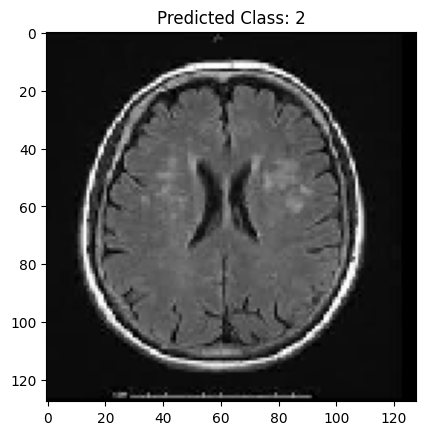

In [ ]:
img, label = next(test_data)

pred = model.predict(img)

plt.imshow(img[0])
plt.title("Predicted Class: " + str(np.argmax(pred[0])))
plt.show()